<a href="https://colab.research.google.com/github/JacobeJonathan/DATAVISUALIZATION---MASTER/blob/main/Caso_2_(Mercado_de_ETFs).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ── CELDA 0: Instalaciones ──────────────────────────────────────────────────
# squarify para el treemap (matplotlib ya viene en Colab)
!pip install squarify --quiet
print('✅ Listo')

✅ Listo


In [ ]:
# ── CELDA 1: Datos ──────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import squarify

# AUM en miles de millones USD
labels = [
    'Equities',
    'Bonds',
    'Commodities',
    'Currencies',
    'Other',
    'Real Estate',
]
values = np.array([10_500, 2_200, 318, 160, 102, 77])
total  = values.sum()
pcts   = values / total * 100

# Paleta monocromática azul (Knaflic: color con propósito, no decoración)
BLUES = ['#0C447C', '#185FA5', '#378ADD', '#85B7EB', '#B5D4F4', '#D6E9F8', '#EAF3FB']
BG        = '#FAFAF8'
GRAY_TEXT = '#444441'
GRAY_MID  = '#888780'

print(f'Total AUM: ${total/1000:.1f}T')
for l, v, p in zip(labels, values, pcts):
    tag = f'${v/1000:.2f}T' if v >= 1000 else f'${v}B'
    print(f'  {l:<22} {tag:>9}   {p:5.1f}%')

Total AUM: $13.4T
  Equities                 $10.50T    78.6%
  Bonds                     $2.20T    16.5%
  Commodities                $318B     2.4%
  Currencies                 $160B     1.2%
  Other                      $102B     0.8%
  Real Estate                 $77B     0.6%


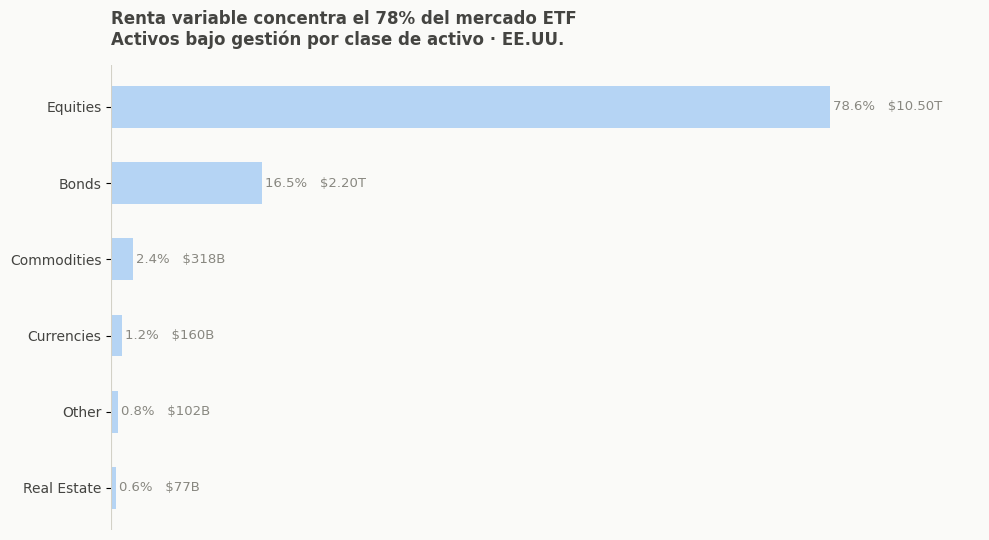

Guardado: grafico2_barras_horizontales.png


In [ ]:
# ── CELDA 4: Gráfico 2 — Barras horizontales ordenadas ──────────────────────

order  = np.argsort(values)
labs_s = [labels[i] for i in order]
vals_s = values[order]
pcts_s = pcts[order]

bar_colors = ['#0C447C' if 'variable' in l else '#B5D4F4' for l in labs_s]
y_pos      = np.arange(len(labs_s))

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

ax.barh(y_pos, pcts_s, color=bar_colors, height=0.55, linewidth=0)

for i, (val, pct, col) in enumerate(zip(vals_s, pcts_s, bar_colors)):
    tag      = f'${val/1000:.2f}T' if val >= 1000 else f'${val}B'
    is_main  = col == '#0C447C'
    ax.text(pct + 0.3, i, f'{pct:.1f}%   {tag}',
            va='center', fontsize=9.5,
            color='#0C447C' if is_main else GRAY_MID,
            fontweight='bold' if is_main else 'normal')

ax.set_yticks(y_pos)
ax.set_yticklabels(labs_s, fontsize=10, color=GRAY_TEXT)
ax.set_xlim(0, 95)
ax.xaxis.set_visible(False)
ax.axvline(0, color='#D3D1C7', linewidth=0.8)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title(
    'Renta variable concentra el 78% del mercado ETF\n'
    'Activos bajo gestión por clase de activo · EE.UU.',
    fontsize=12, fontweight='bold', color=GRAY_TEXT, loc='left', pad=14)

plt.tight_layout()
plt.savefig('grafico2_barras_horizontales.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: grafico2_barras_horizontales.png')

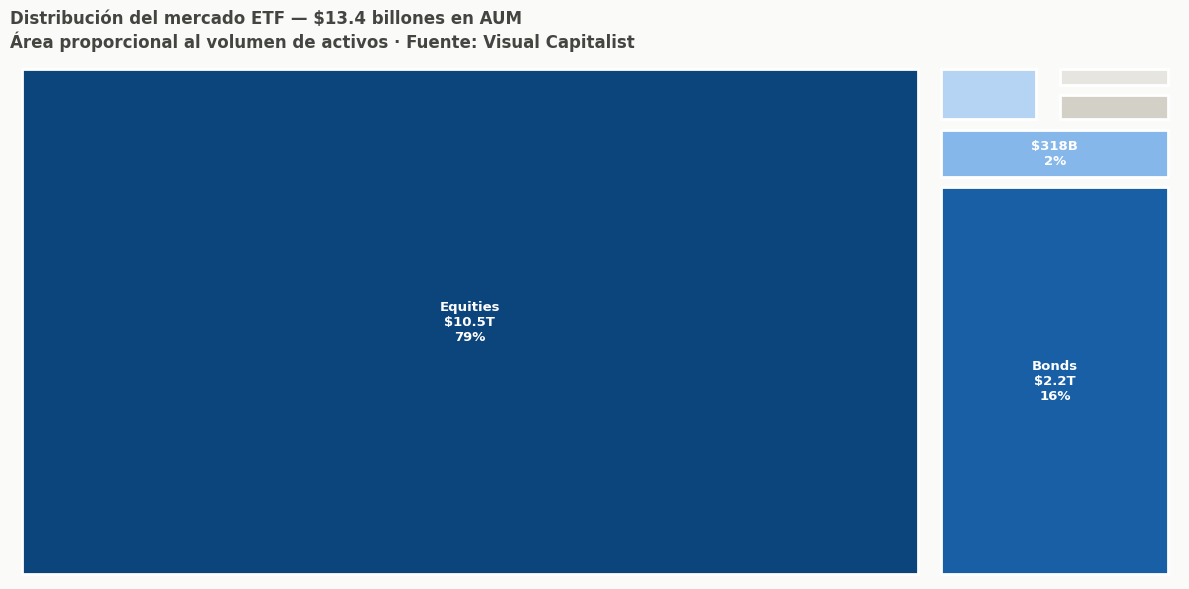

Guardado: grafico3_treemap.png


In [ ]:
# ── CELDA 5: Gráfico 3 — Treemap proporcional ───────────────────────────────

treemap_colors = ['#0C447C','#185FA5','#85B7EB','#B5D4F4','#D3D1C7','#E6E5DF','#F1EFE8']

treemap_labels = []
for lbl, val, pct in zip(labels, values, pcts):
    tag = f'${val/1000:.1f}T' if val >= 1000 else f'${val}B'
    if pct >= 4:
        treemap_labels.append(f'{lbl}\n{tag}\n{pct:.0f}%')
    elif pct >= 1.5:
        treemap_labels.append(f'{tag}\n{pct:.0f}%')
    else:
        treemap_labels.append('')

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

squarify.plot(
    sizes=values,
    label=treemap_labels,
    color=treemap_colors,
    alpha=1,
    ax=ax,
    text_kwargs={'fontsize': 9.5, 'color': 'white',
                 'fontweight': 'bold'},
    pad=True,
    bar_kwargs=dict(linewidth=2, edgecolor='white')
)

ax.set_axis_off()
ax.set_title(
    f'Distribución del mercado ETF — ${total/1000:.1f} billones en AUM\n'
    'Área proporcional al volumen de activos · Fuente: Visual Capitalist',
    fontsize=12, fontweight='bold', color=GRAY_TEXT, loc='left', pad=12)

plt.tight_layout()
plt.savefig('grafico3_treemap.png', dpi=180,
            bbox_inches='tight', facecolor=BG)
plt.show()
print('Guardado: grafico3_treemap.png')